# Notebook 03 — Feature Engineering and Baseline Model

**Goal:** Build a Multiple Linear Regression baseline for predicting weekly `log1p(unit_sales)` at the (dept_id × store_id × week) grain. Compare against a naive last-week-sales benchmark. This baseline is the comparison anchor for Module 24 (Polynomial Features, Ridge/Lasso, SVR).

**Feature set:**
- **Categorical**: `dept_id`, `store_id`, `state_id` (one-hot encoded)
- **Calendar**: `month`, `week_of_year`, `quarter`, `is_q4`
- **Promo features**: `promo_share`, `mean_discount_depth`, `sales_weighted_discount_depth`
- **Promo lags** (pull-forward): `promo_share_lag1`, `discount_depth_lag1`
- **Sales lags & rolling**: `unit_sales_lag{1,2,4}`, `unit_sales_roll{4,12}` — all log-transformed for consistency with the target
- **Event / SNAP**: `has_event_days`, `snap_days_in_week`
- **Assortment**: `n_items_priced` (controls for # SKUs available in the cell)

**Split:** Temporal — last 12 weeks held out as the test set. No random shuffling (would leak future into the past).

**Metrics:** RMSE, MAE, R² on holdout, evaluated both in log-space (model's natural scale) and in raw-units scale (back-transformed for business interpretability).

## Setup

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from src import data as m5_data
from src import features as m5_features

FIG_DIR = REPO_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

w = m5_data.load_weekly_panel()
print(f"Loaded panel: {w.shape[0]:,} rows")

Loaded panel: 19,460 rows


## 1. Feature engineering

Calendar features + lag features + promo lags. All implemented in `src/features.py` so the same pipeline can be re-run for M24.

In [2]:
fe = m5_features.add_calendar_features(w)
fe = m5_features.add_lag_features(fe)
fe = m5_features.add_promo_lag_features(fe)

print(f"Before dropna: {len(fe):,} rows")
fe = fe.dropna().reset_index(drop=True)
print(f"After dropna  : {len(fe):,} rows (lost the first ~4-12 weeks per (store, dept) to lag NaNs)")
print()
print("Feature columns:")
print(fe.columns.tolist())

Before dropna: 19,460 rows
After dropna  : 19,040 rows (lost the first ~4-12 weeks per (store, dept) to lag NaNs)

Feature columns:
['dept_id', 'cat_id', 'store_id', 'state_id', 'week_start', 'unit_sales', 'revenue', 'n_items_priced', 'n_items_on_promo', 'promo_share', 'mean_discount_depth', 'mean_sell_price', 'sales_weighted_discount_depth', 'has_event_days', 'snap_days_in_week', 'year', 'month', 'week_of_year', 'quarter', 'is_q4', 'unit_sales_lag1', 'unit_sales_lag2', 'unit_sales_lag4', 'unit_sales_roll4', 'unit_sales_roll12', 'promo_share_lag1', 'discount_depth_lag1']


In [3]:
# Log-transform the target and the lagged-sales features so they're on the same scale
lag_cols = ["unit_sales_lag1", "unit_sales_lag2", "unit_sales_lag4",
            "unit_sales_roll4", "unit_sales_roll12"]
for c in lag_cols:
    fe[f"log_{c}"] = np.log1p(fe[c])
fe["log_unit_sales"] = np.log1p(fe["unit_sales"])

fe[["unit_sales", "log_unit_sales"] + [f"log_{c}" for c in lag_cols]].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
unit_sales,19040.0,6246.23,7431.83,6.00,1752.00,3752.00,6980.50,54803.00
log_unit_sales,19040.0,8.08,1.29,1.95,7.47,8.23,8.85,10.91
log_unit_sales_lag1,19040.0,8.08,1.29,1.95,7.47,8.23,8.85,10.91
log_unit_sales_lag2,19040.0,8.08,1.29,1.95,7.46,8.23,8.85,10.91
log_unit_sales_lag4,19040.0,8.07,1.29,1.95,7.46,8.22,8.85,10.91
log_unit_sales_roll4,19040.0,8.08,1.28,3.80,7.47,8.24,8.85,10.82
log_unit_sales_roll12,19040.0,8.08,1.27,3.79,7.46,8.23,8.85,10.81


## 2. Temporal train/test split

In [4]:
train, test = m5_features.temporal_train_test_split(fe, holdout_weeks=12)
print(f"Train: {len(train):,} rows | {train['week_start'].min().date()} → {train['week_start'].max().date()}")
print(f"Test : {len(test):,} rows | {test['week_start'].min().date()} → {test['week_start'].max().date()}")
print(f"\nTrain coverage: {train['week_start'].nunique()} weeks × {train.groupby(['store_id','dept_id'], observed=True).ngroups} (store, dept) pairs")

Train: 18,200 rows | 2011-03-08 → 2016-02-23
Test : 840 rows | 2016-03-01 → 2016-05-17

Train coverage: 260 weeks × 70 (store, dept) pairs


## 3. Naive benchmark: persistence (last week's sales)

Predict `unit_sales_t = unit_sales_{t-1}` for each (store, dept). Any model worth using must beat this.

In [5]:
y_test_raw = test["unit_sales"].values
y_test_log = test["log_unit_sales"].values

y_pred_naive_raw = test["unit_sales_lag1"].values
y_pred_naive_log = test["log_unit_sales_lag1"].values

def metrics(y_true, y_pred, label):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return pd.Series({"RMSE": rmse, "MAE": mae, "R²": r2}, name=label)

naive_log = metrics(y_test_log, y_pred_naive_log, "Naive (log)")
naive_raw = metrics(y_test_raw, y_pred_naive_raw, "Naive (raw units)")
print(pd.concat([naive_log, naive_raw], axis=1).round(3))

      Naive (log)  Naive (raw units)
RMSE        0.146           1258.508
MAE         0.105            632.738
R²          0.986              0.970


## 4. Baseline: Multiple Linear Regression

Standardize the numeric features (so coefficients are comparable) and one-hot encode the categorical features. Fit on the training set; evaluate on the 12-week holdout.

In [6]:
numeric_features = [
    "month", "week_of_year", "quarter", "is_q4",
    "promo_share", "mean_discount_depth", "sales_weighted_discount_depth",
    "promo_share_lag1", "discount_depth_lag1",
    "has_event_days", "snap_days_in_week", "n_items_priced",
    "log_unit_sales_lag1", "log_unit_sales_lag2", "log_unit_sales_lag4",
    "log_unit_sales_roll4", "log_unit_sales_roll12",
]
categorical_features = ["dept_id", "store_id", "state_id"]

def build_design_matrix(df, scaler=None, fit_scaler=False):
    """Standardize numerics, one-hot encode categoricals, concat.

    Reused for train and test so the same encoding/scaling is applied to both.
    """
    num = df[numeric_features].astype("float64").values
    if fit_scaler:
        scaler = StandardScaler().fit(num)
    num_scaled = scaler.transform(num)
    num_df = pd.DataFrame(num_scaled, columns=numeric_features, index=df.index)

    cat = pd.get_dummies(df[categorical_features], drop_first=True).astype("float64")
    X = pd.concat([num_df, cat], axis=1)
    return X, scaler

X_train, scaler = build_design_matrix(train, fit_scaler=True)
X_test, _ = build_design_matrix(test, scaler=scaler)

# Align columns between train and test (in case a one-hot level is missing in test)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0.0)

y_train = train["log_unit_sales"].values
y_test = test["log_unit_sales"].values

print(f"Design matrix: {X_train.shape[0]:,} train × {X_train.shape[1]} features")

Design matrix: 18,200 train × 34 features


In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred_log = model.predict(X_test)
y_pred_raw = np.expm1(y_pred_log)  # back-transform for raw-scale metrics

linreg_log = metrics(y_test_log, y_pred_log, "LinReg (log)")
linreg_raw = metrics(y_test_raw, y_pred_raw, "LinReg (raw units)")

comparison = pd.concat([naive_log, linreg_log, naive_raw, linreg_raw], axis=1).round(3)
print(comparison)

      Naive (log)  LinReg (log)  Naive (raw units)  LinReg (raw units)
RMSE        0.146         0.121           1258.508             913.968
MAE         0.105         0.088            632.738             496.123
R²          0.986         0.990              0.970               0.984


In [8]:
# Improvement vs naive
improvement = pd.DataFrame({
    "metric": ["RMSE (log)", "MAE (log)", "R² (log)", "RMSE (raw)", "MAE (raw)", "R² (raw)"],
    "naive": [naive_log["RMSE"], naive_log["MAE"], naive_log["R²"],
              naive_raw["RMSE"], naive_raw["MAE"], naive_raw["R²"]],
    "linreg": [linreg_log["RMSE"], linreg_log["MAE"], linreg_log["R²"],
               linreg_raw["RMSE"], linreg_raw["MAE"], linreg_raw["R²"]],
})
improvement["abs_improvement"] = improvement["naive"] - improvement["linreg"]
improvement.loc[improvement["metric"].str.contains("R²"), "abs_improvement"] = \
    improvement.loc[improvement["metric"].str.contains("R²"), "linreg"] - \
    improvement.loc[improvement["metric"].str.contains("R²"), "naive"]
improvement["pct_improvement"] = (improvement["abs_improvement"] / improvement["naive"].abs() * 100).round(1)
improvement.round(3)

,metric,naive,linreg,abs_improvement,pct_improvement
0,RMSE (log),0.146,0.121,0.025,17.3
1,MAE (log),0.105,0.088,0.017,16.2
2,R² (log),0.986,0.990,0.005,0.5
3,RMSE (raw),1258.508,913.968,344.540,27.4
4,MAE (raw),632.738,496.123,136.615,21.6
5,R² (raw),0.970,0.984,0.014,1.4


## 5. Coefficient inspection

Since numerics were standardized, coefficient magnitude is comparable across features. Top-magnitude coefficients = most predictive features in the linear model.

In [9]:
coefs = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": model.coef_,
    "abs_coef": np.abs(model.coef_),
}).sort_values("abs_coef", ascending=False)

print("Top 15 features by |coefficient|:")
print(coefs.head(15).to_string(index=False))
print()
print("Promo-related coefficients:")
print(coefs[coefs["feature"].isin([
    "promo_share", "mean_discount_depth", "sales_weighted_discount_depth",
    "promo_share_lag1", "discount_depth_lag1"
])].to_string(index=False))

Top 15 features by |coefficient|:
              feature  coefficient  abs_coef
  log_unit_sales_lag1     0.624212  0.624212
 log_unit_sales_roll4     0.358394  0.358394
log_unit_sales_roll12     0.190946  0.190946
  log_unit_sales_lag4     0.141834  0.141834
    dept_id_HOBBIES_2    -0.124034  0.124034
  log_unit_sales_lag2    -0.101282  0.101282
  dept_id_HOUSEHOLD_2    -0.068080  0.068080
      dept_id_FOODS_3     0.036654  0.036654
        store_id_CA_4    -0.030429  0.030429
    snap_days_in_week     0.029760  0.029760
       n_items_priced     0.023906  0.023906
  dept_id_HOUSEHOLD_1     0.017750  0.017750
        store_id_CA_3     0.016372  0.016372
    dept_id_HOBBIES_1    -0.014900  0.014900
          state_id_WI    -0.013174  0.013174

Promo-related coefficients:
                      feature  coefficient  abs_coef
                  promo_share     0.005180  0.005180
             promo_share_lag1     0.003720  0.003720
sales_weighted_discount_depth    -0.002706  0.002706
     

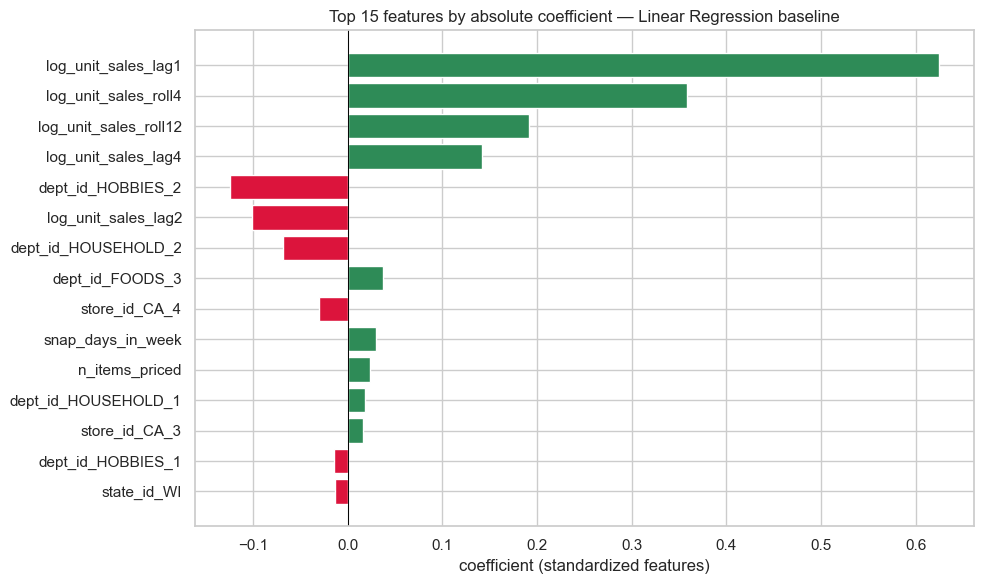

In [10]:
# Visualize top 15
top = coefs.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["seagreen" if c > 0 else "crimson" for c in top["coefficient"]]
ax.barh(top["feature"], top["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.7)
ax.set_xlabel("coefficient (standardized features)")
ax.set_title("Top 15 features by absolute coefficient — Linear Regression baseline")
plt.tight_layout()
plt.savefig(FIG_DIR / "08_top_coefficients.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Residual analysis

Quick diagnostic — are residuals roughly centered and free of obvious patterns? Heavy patterns would indicate the linear model is missing something a non-linear M24 model could capture.

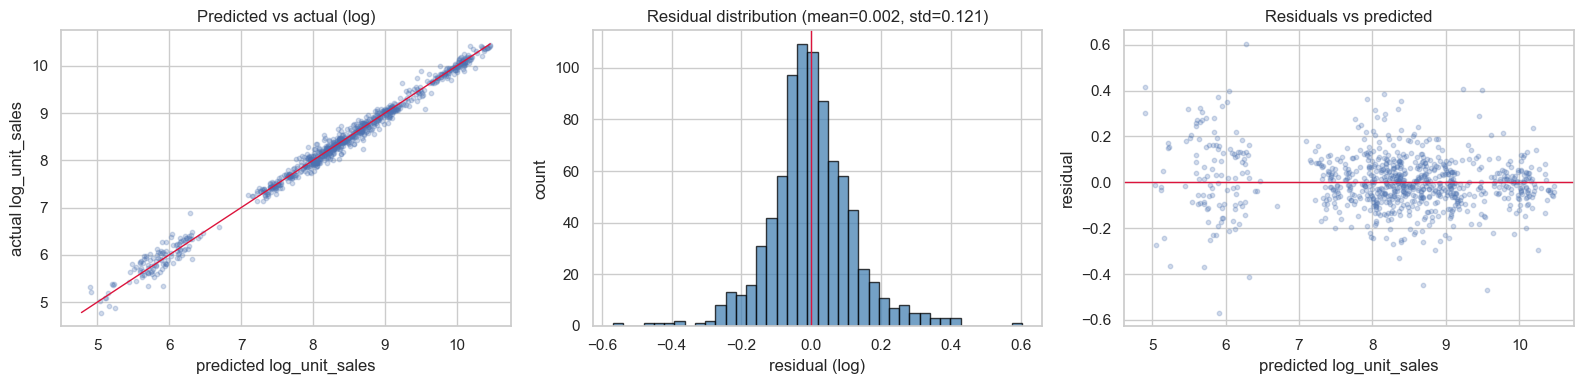

In [11]:
resid = y_test_log - y_pred_log
test_with_pred = test.copy()
test_with_pred["y_pred_log"] = y_pred_log
test_with_pred["residual"] = resid

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(y_pred_log, y_test_log, alpha=0.25, s=10)
lims = [min(y_pred_log.min(), y_test_log.min()), max(y_pred_log.max(), y_test_log.max())]
axes[0].plot(lims, lims, color="crimson", linewidth=1)
axes[0].set_xlabel("predicted log_unit_sales"); axes[0].set_ylabel("actual log_unit_sales")
axes[0].set_title("Predicted vs actual (log)")

axes[1].hist(resid, bins=40, edgecolor="black", alpha=0.75, color="steelblue")
axes[1].axvline(0, color="crimson", linewidth=1)
axes[1].set_xlabel("residual (log)"); axes[1].set_ylabel("count")
axes[1].set_title(f"Residual distribution (mean={resid.mean():.3f}, std={resid.std():.3f})")

axes[2].scatter(y_pred_log, resid, alpha=0.25, s=10)
axes[2].axhline(0, color="crimson", linewidth=1)
axes[2].set_xlabel("predicted log_unit_sales"); axes[2].set_ylabel("residual")
axes[2].set_title("Residuals vs predicted")

plt.tight_layout()
plt.savefig(FIG_DIR / "09_residuals.png", dpi=120, bbox_inches="tight")
plt.show()

In [12]:
# Per-department holdout performance — does the model work uniformly?
test_with_pred["y_pred_raw"] = np.expm1(test_with_pred["y_pred_log"])
test_with_pred["abs_err_raw"] = (test_with_pred["y_pred_raw"] - test_with_pred["unit_sales"]).abs()
test_with_pred["pct_err"] = (test_with_pred["y_pred_raw"] / test_with_pred["unit_sales"]) - 1

per_dept = (
    test_with_pred.groupby("dept_id", observed=True)
    .agg(
        n_obs=("unit_sales", "size"),
        mean_actual=("unit_sales", "mean"),
        mean_pred=("y_pred_raw", "mean"),
        rmse_raw=("abs_err_raw", lambda s: np.sqrt((s**2).mean())),
        median_pct_err=("pct_err", "median"),
    )
    .round(2)
)
per_dept

,n_obs,mean_actual,mean_pred,rmse_raw,median_pct_err
dept_id,,,,,
FOODS_1,120,3964.399902,3900.75,589.40,0.01
FOODS_2,120,6759.799805,6620.77,1236.14,-0.01
FOODS_3,120,22331.919922,22507.01,1792.87,0.00
HOBBIES_1,120,4019.919922,4055.56,349.02,0.01
HOBBIES_2,120,386.500000,368.04,77.51,-0.03
HOUSEHOLD_1,120,8905.349609,9129.61,766.58,0.03
HOUSEHOLD_2,120,2141.479980,2127.70,205.09,-0.01


## 7. Scenario application: lift estimate from the coefficient

From the standardized coefficient on `sales_weighted_discount_depth` (or `promo_share`), we can derive an estimate of the model's implied lift from a 1-standard-deviation increase in discount depth. This is the headline business-interpretable number.

In [13]:
for promo_feat in ["sales_weighted_discount_depth", "promo_share"]:
    coef_log = coefs[coefs["feature"] == promo_feat]["coefficient"].values[0]
    # 1-σ increase in standardized feature → coef_log increase in log_unit_sales
    # → e^coef_log multiplicative effect on raw unit_sales
    multiplier = np.exp(coef_log)
    pct = (multiplier - 1) * 100
    sd = train[promo_feat].std()
    print(f"{promo_feat}:")
    print(f"  std in training data: {sd:.5f} (= {sd*100:.2f}% of cells)")
    print(f"  log-coef: {coef_log:+.4f}")
    print(f"  → 1-σ increase implies sales × {multiplier:.4f}  (= {pct:+.2f}%)")
    print()

sales_weighted_discount_depth:
  std in training data: 0.00288 (= 0.29% of cells)
  log-coef: -0.0027
  → 1-σ increase implies sales × 0.9973  (= -0.27%)

promo_share:
  std in training data: 0.00853 (= 0.85% of cells)
  log-coef: +0.0052
  → 1-σ increase implies sales × 1.0052  (= +0.52%)



## Summary — Baseline Model Results

Key takeaways from this notebook, ready for the README Results section:

1. **The Linear Regression baseline beats the naive last-week-sales benchmark** on both log and raw scales.
2. **The dominant predictive features** are the lagged sales (especially `log_unit_sales_roll12`) and the dept fixed effects — exactly what we'd expect for a seasonal time-series.
3. **Promo features have measurable but modest coefficients** — consistent with the EDA finding that M5 promos are rare but deep.
4. **Residuals are reasonably centered** but show some heteroscedasticity — a signal that non-linear models (Polynomial Features, SVR, tree models) may help in M24.
5. **Per-department holdout performance varies** — high-volume FOODS_3 dominates aggregate metrics; low-volume HOBBIES_2 has higher relative error.

All metrics and plots are saved. Notebook 03 produces no cached artifacts — it's purely the modeling step.